In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from brokenaxes import brokenaxes
import matplotlib.patches as patches
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter

In [2]:
fig_length = {1 : 3.50394,    # 1 column
              1.5 : 5.35433, # 1.5 columns
              2 : 7.20472}    # 2 columns
fig_height = 9.72441 # maximum height
fontsize_title = 9
fontsize_label = 8
fontsize_legend = 8
fontsize_axs = 8

plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({'font.size' : 8})
plt.rcParams['font.family'] = 'Arial'

In [3]:
hydrogenResultsPath = os.path.join('..', 'Results', 'Phase 2', 'Hydrogen')
hydrogenResults = {}
impactCategories = []
for fileName in os.listdir(hydrogenResultsPath):
    if fileName.endswith('.xlsx') and 'breakdown' not in fileName:
        filePath = os.path.join(hydrogenResultsPath, fileName)
        impactCategory = fileName.replace('hydrogen ', '')
        impactCategory = impactCategory.replace(' results.xlsx', '')
        impactCategories.append(impactCategory)
        dfs = pd.read_excel(filePath, sheet_name = None)
        dfAll = []
        for df in dfs.items():
            database = df[0]
            df = df[1]
            numCols = len(df.columns) - 1
            repeatedActivity = np.repeat(df['Activity'], numCols)
            dfNew = pd.DataFrame({
                'Activity' : repeatedActivity,
                'Location' : np.tile(df.columns[1:], len(df)),
                'Impact' : df.iloc[:, 1:].values.flatten(),
                'Database' : database
            })
            dfAll.append(dfNew)
        totalImpactCatDF = pd.concat(dfAll, ignore_index = True)
    hydrogenResults[impactCategory] = totalImpactCatDF

for dfName, df in hydrogenResults.items():
    filteredDF = df[df['Location'] == 'GLO']
    hydrogenResults[dfName] = filteredDF

In [4]:
ammoniaResultsPath = os.path.join('..', 'Results', 'Phase 2', 'Ammonia')
ammoniaResults = {}
impactCategories = []
for fileName in os.listdir(ammoniaResultsPath):
    if fileName.endswith('.xlsx') and 'breakdown' not in fileName:
        filePath = os.path.join(ammoniaResultsPath, fileName)
        impactCategory = fileName.replace('ammonia ', '')
        impactCategory = impactCategory.replace(' results.xlsx', '')
        impactCategories.append(impactCategory)
        dfs = pd.read_excel(filePath, sheet_name = None)
        dfAll = []
        for df in dfs.items():
            database = df[0]
            df = df[1]
            numCols = len(df.columns) - 1
            repeatedActivity = np.repeat(df['Activity'], numCols)
            dfNew = pd.DataFrame({
                'Activity' : repeatedActivity,
                'Location' : np.tile(df.columns[1:], len(df)),
                'Impact' : df.iloc[:, 1:].values.flatten(),
                'Database' : database
            })
            dfAll.append(dfNew)
        totalImpactCatDF = pd.concat(dfAll, ignore_index = True)
    ammoniaResults[impactCategory] = totalImpactCatDF

for dfName, df in ammoniaResults.items():
    filteredDF = df[df['Location'] == 'GLO']
    ammoniaResults[dfName] = filteredDF

In [5]:
methanolResultsPath = os.path.join('..', 'Results', 'Phase 2', 'Methanol')
methanolResults = {}
impactCategories = []
for fileName in os.listdir(methanolResultsPath):
    if fileName.endswith('.xlsx') and 'breakdown' not in fileName:
        filePath = os.path.join(methanolResultsPath, fileName)
        impactCategory = fileName.replace('methanol ', '')
        impactCategory = impactCategory.replace(' results.xlsx', '')
        impactCategories.append(impactCategory)
        dfs = pd.read_excel(filePath, sheet_name = None)
        dfAll = []
        for df in dfs.items():
            database = df[0]
            df = df[1]
            numCols = len(df.columns) - 1
            repeatedActivity = np.repeat(df['Activity'], numCols)
            dfNew = pd.DataFrame({
                'Activity' : repeatedActivity,
                'Location' : np.tile(df.columns[1:], len(df)),
                'Impact' : df.iloc[:, 1:].values.flatten(),
                'Database' : database
            })
            dfAll.append(dfNew)
        totalImpactCatDF = pd.concat(dfAll, ignore_index = True)
    methanolResults[impactCategory] = totalImpactCatDF

for dfName, df in methanolResults.items():
    filteredDF = df[df['Location'] == 'GLO']
    methanolResults[dfName] = filteredDF

In [6]:
ethyleneResultsPath = os.path.join('..', 'Results', 'Phase 2', 'Ethylene')
ethyleneResults = {}
impactCategories = []
for fileName in os.listdir(ethyleneResultsPath):
    if fileName.endswith('.xlsx') and 'breakdown' not in fileName:
        filePath = os.path.join(ethyleneResultsPath, fileName)
        impactCategory = fileName.replace('ethylene ', '')
        impactCategory = impactCategory.replace(' results.xlsx', '')
        impactCategories.append(impactCategory)
        dfs = pd.read_excel(filePath, sheet_name = None)
        dfAll = []
        for df in dfs.items():
            database = df[0]
            df = df[1]
            numCols = len(df.columns) - 1
            repeatedActivity = np.repeat(df['Activity'], numCols)
            dfNew = pd.DataFrame({
                'Activity' : repeatedActivity,
                'Location' : np.tile(df.columns[1:], len(df)),
                'Impact' : df.iloc[:, 1:].values.flatten(),
                'Database' : database
            })
            dfAll.append(dfNew)
        totalImpactCatDF = pd.concat(dfAll, ignore_index = True)
    ethyleneResults[impactCategory] = totalImpactCatDF

for dfName, df in ethyleneResults.items():
    filteredDF = df[df['Location'] == 'GLO']
    ethyleneResults[dfName] = filteredDF

In [7]:
impactCategories.sort()
impactCategories

['acidification',
 'climate change',
 'ecotoxicity freshwater',
 'eutrophication freshwater',
 'eutrophication marine',
 'eutrophication terrestrial',
 'human toxicity carcinogenic',
 'human toxicity non-carcinogenic',
 'ionising radiation',
 'land use',
 'ozone depletion',
 'particulate matter',
 'photochemical ozone formation',
 'resource use fossils',
 'resource use mineral and metals',
 'water use']

In [8]:
years = ['2020', '2030', '2040', '2050']
alphabets = ['a ', 'b ', 'c ', 'd ', 'e ', 'f ', 'g ', 'h ', 'i ', 'j ', 'k ', 'l ', 'm ', 'n ', 'o ', 'p ']

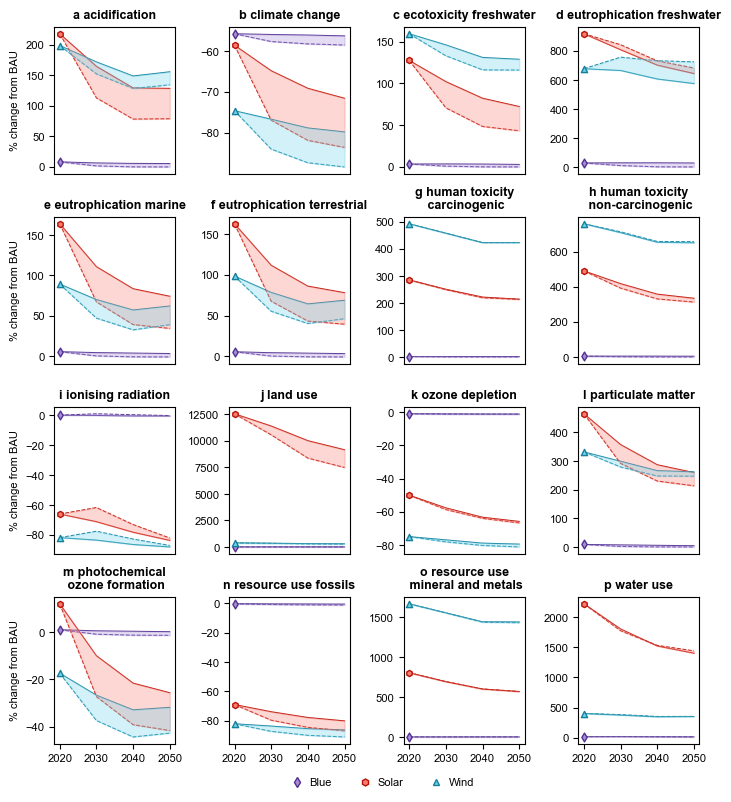

In [9]:
fig, ax = plt.subplots(4, 4, figsize = (fig_length[2], fig_height*0.8))

for i in range(0, len(impactCategories)):

    hydrogenResult = hydrogenResults[impactCategories[i]]
    hydrogenResultsRCP6 = hydrogenResult[hydrogenResult['Database'].str.contains('Base')]
    hydrogenBAURCP6 = hydrogenResultsRCP6[hydrogenResultsRCP6['Activity'].str.contains('hydrogen production without electricity, steam reforming of natural gas, 25 bar')]
    hydrogenBlueRCP6 = hydrogenResultsRCP6[hydrogenResultsRCP6['Activity'].str.contains(r'hydrogen production without electricity, steam methane reforming of natural gas, with CCS (MDEA, 98% eff.), 25 bar', regex = False)]
    hydrogenWindRCP6 = hydrogenResultsRCP6[hydrogenResultsRCP6['Activity'].str.contains('onshore wind')]
    hydrogenSolarRCP6 = hydrogenResultsRCP6[hydrogenResultsRCP6['Activity'].str.contains('solar')]

    hydrogenResultsRCP19 = hydrogenResult[hydrogenResult['Database'].str.contains('Base 2020') | hydrogenResult['Database'].str.contains('RCP19')]
    hydrogenBAURCP19 = hydrogenResultsRCP19[hydrogenResultsRCP19['Activity'].str.contains('hydrogen production without electricity, steam reforming of natural gas, 25 bar')]
    hydrogenBlueRCP19 = hydrogenResultsRCP19[hydrogenResultsRCP19['Activity'].str.contains(r'hydrogen production without electricity, steam methane reforming of natural gas, with CCS (MDEA, 98% eff.), 25 bar', regex = False)]
    hydrogenWindRCP19 = hydrogenResultsRCP19[hydrogenResultsRCP19['Activity'].str.contains('onshore wind')]
    hydrogenSolarRCP19 = hydrogenResultsRCP19[hydrogenResultsRCP19['Activity'].str.contains('solar')]

    hydrogenBAURCP6 = hydrogenBAURCP6.reset_index(drop=True)
    hydrogenBlueRCP6 = hydrogenBlueRCP6.reset_index(drop=True)
    hydrogenWindRCP6 = hydrogenWindRCP6.reset_index(drop = True)
    hydrogenSolarRCP6 = hydrogenSolarRCP6.reset_index(drop = True)
    blueRCP6 = (hydrogenBlueRCP6['Impact'] - hydrogenBAURCP6['Impact'])/hydrogenBAURCP6['Impact']*100
    windRCP6 = (hydrogenWindRCP6['Impact'] - hydrogenBAURCP6['Impact'])/hydrogenBAURCP6['Impact']*100
    solarRCP6 = (hydrogenSolarRCP6['Impact'] - hydrogenBAURCP6['Impact'])/hydrogenBAURCP6['Impact']*100

    hydrogenBAURCP19 = hydrogenBAURCP19.reset_index(drop=True)
    hydrogenBlueRCP19 = hydrogenBlueRCP19.reset_index(drop=True)
    hydrogenWindRCP19 = hydrogenWindRCP19.reset_index(drop = True)
    hydrogenSolarRCP19 = hydrogenSolarRCP19.reset_index(drop = True)
    blueRCP19 = (hydrogenBlueRCP19['Impact'] - hydrogenBAURCP19['Impact'])/hydrogenBAURCP19['Impact']*100
    windRCP19 = (hydrogenWindRCP19['Impact'] - hydrogenBAURCP19['Impact'])/hydrogenBAURCP19['Impact']*100
    solarRCP19 = (hydrogenSolarRCP19['Impact'] - hydrogenBAURCP19['Impact'])/hydrogenBAURCP19['Impact']*100

    ax[i // 4, i % 4].plot(years, blueRCP6, label = 'Blue', color = '#52318E', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, solarRCP6, label = 'Solar', color = '#B71205', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, windRCP6, label = 'Wind', color = '#167F99', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, blueRCP19, label = 'Blue', color = '#52318E', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 4, i % 4].plot(years, solarRCP19, label = 'Solar', color = '#B71205', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 4, i % 4].plot(years, windRCP19, label = 'Wind', color = '#167F99', zorder = 0, linewidth = 0.75, linestyle = '--')

    ax[i//4, i % 4].fill_between(years, blueRCP6, blueRCP19, color = '#A78DD8', alpha = 0.3, zorder = 0)
    ax[i//4, i % 4].fill_between(years, solarRCP6, solarRCP19, color = '#FB7B71', alpha = 0.3, zorder = 0)
    ax[i//4, i % 4].fill_between(years, windRCP6, windRCP19, color = '#6DD2EA', alpha = 0.3, zorder = 0)

    ax[i // 4, i % 4].scatter(years[0], blueRCP6[0], label = 'Blue', s = 20, 
                              marker = 'd', facecolor = '#A78DD8', edgecolors = '#52318E', zorder = 1)
    ax[i // 4, i % 4].scatter(years[0], solarRCP6[0], label = 'Solar', s = 20, 
                              marker = 'h', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 1)
    ax[i // 4, i % 4].scatter(years[0], windRCP6[0], label = 'Wind', s = 20, 
                              marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 1)
    

    ax[i // 4, i % 4].set_title(alphabets[i] + impactCategories[i], fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'human toxicity carcinogenic':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'human toxicity\n carcinogenic', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'human toxicity non-carcinogenic':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'human toxicity\n non-carcinogenic', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'photochemical ozone formation':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'photochemical\n ozone formation', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'resource use mineral and metals':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'resource use\n mineral and metals', fontweight = 'bold', fontsize = fontsize_title)

for i in range(0, 4):
    for j in range(0, 4):
        if i < 3:
            ax[i, j].set_xticks([])
        if j == 0:
            ax[i, j].set_ylabel(r'% change from BAU')

legend_elements2 = [Line2D([0], [0], marker = 'd', color = "none", 
                                             markerfacecolor ='#A78DD8', markeredgecolor = "#52318E",
                                             label = 'Blue', markersize = 5),
                   Line2D([0], [0], marker = 'h', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar', markersize = 5),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind', markersize = 5),]

legend1 = fig.legend(handles = legend_elements2, frameon = False, loc = "upper center", ncol = 3, 
          prop={"size":8}, bbox_to_anchor=(0.53, 0.01), handletextpad = 0.1)

plotPathPNG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Hydrogen image SSP2 GLO.png')
plotPathSVG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Hydrogen image SSP2 GLO.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')

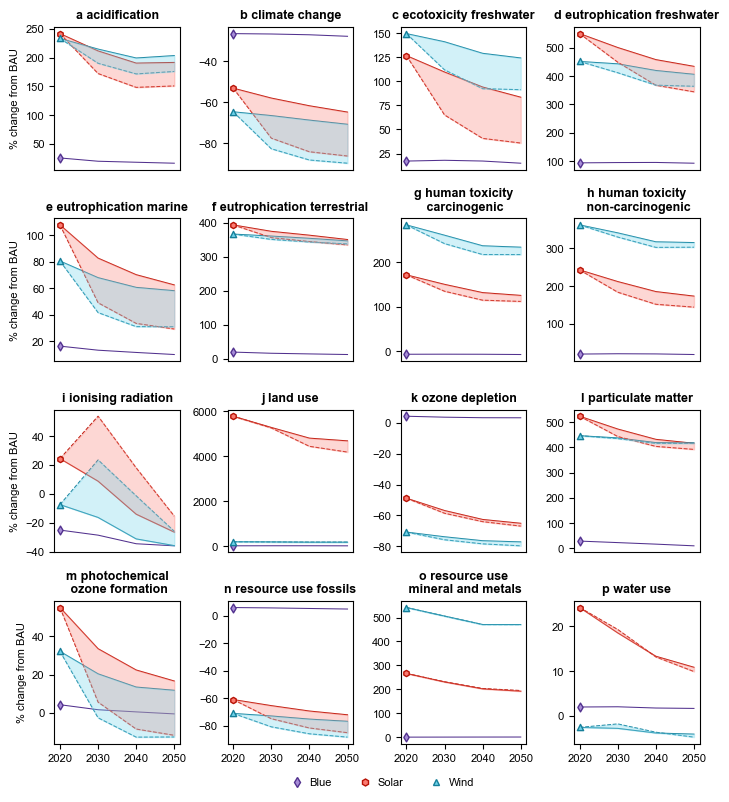

In [10]:
fig, ax = plt.subplots(4, 4, figsize = (fig_length[2], fig_height*0.8))

for i in range(0, len(impactCategories)):

    ammoniaResult = ammoniaResults[impactCategories[i]]
    ammoniaResultsRCP6 = ammoniaResult[ammoniaResult['Database'].str.contains('Base')]
    ammoniaBAURCP6 = ammoniaResultsRCP6[ammoniaResultsRCP6['Activity'].str.contains('ammonia, BAU')]
    ammoniaBlueRCP6 = ammoniaResultsRCP6[ammoniaResultsRCP6['Activity'].str.contains('ammonia, blue')]
    ammoniaWindRCP6 = ammoniaResultsRCP6[ammoniaResultsRCP6['Activity'].str.contains('onshore wind')]
    ammoniaSolarRCP6 = ammoniaResultsRCP6[ammoniaResultsRCP6['Activity'].str.contains('solar')]

    ammoniaResultsRCP19 = ammoniaResult[ammoniaResult['Database'].str.contains('Base 2020') | ammoniaResult['Database'].str.contains('RCP19')]
    ammoniaBAURCP19 = ammoniaResultsRCP19[ammoniaResultsRCP19['Activity'].str.contains('ammonia, BAU')]
    ammoniaBlueRCP19 = ammoniaResultsRCP19[ammoniaResultsRCP19['Activity'].str.contains('ammoni, blue')]
    ammoniaWindRCP19 = ammoniaResultsRCP19[ammoniaResultsRCP19['Activity'].str.contains('onshore wind')]
    ammoniaSolarRCP19 = ammoniaResultsRCP19[ammoniaResultsRCP19['Activity'].str.contains('solar')]

    ammoniaBAURCP6 = ammoniaBAURCP6.reset_index(drop=True)
    ammoniaBlueRCP6 = ammoniaBlueRCP6.reset_index(drop=True)
    ammoniaWindRCP6 = ammoniaWindRCP6.reset_index(drop = True)
    ammoniaSolarRCP6 = ammoniaSolarRCP6.reset_index(drop = True)
    blueRCP6 = (ammoniaBlueRCP6['Impact'] - ammoniaBAURCP6['Impact'])/ammoniaBAURCP6['Impact']*100
    windRCP6 = (ammoniaWindRCP6['Impact'] - ammoniaBAURCP6['Impact'])/ammoniaBAURCP6['Impact']*100
    solarRCP6 = (ammoniaSolarRCP6['Impact'] - ammoniaBAURCP6['Impact'])/ammoniaBAURCP6['Impact']*100

    ammoniaBAURCP19 = ammoniaBAURCP19.reset_index(drop=True)
    ammoniaBlueRCP19 = ammoniaBlueRCP19.reset_index(drop=True)
    ammoniaWindRCP19 = ammoniaWindRCP19.reset_index(drop = True)
    ammoniaSolarRCP19 = ammoniaSolarRCP19.reset_index(drop = True)
    blueRCP19 = (ammoniaBlueRCP19['Impact'] - ammoniaBAURCP19['Impact'])/ammoniaBAURCP19['Impact']*100
    windRCP19 = (ammoniaWindRCP19['Impact'] - ammoniaBAURCP19['Impact'])/ammoniaBAURCP19['Impact']*100
    solarRCP19 = (ammoniaSolarRCP19['Impact'] - ammoniaBAURCP19['Impact'])/ammoniaBAURCP19['Impact']*100

    ax[i // 4, i % 4].plot(years, blueRCP6, label = 'Blue', color = '#52318E', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, solarRCP6, label = 'Solar', color = '#B71205', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, windRCP6, label = 'Wind', color = '#167F99', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, blueRCP19, label = 'Blue', color = '#52318E', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 4, i % 4].plot(years, solarRCP19, label = 'Solar', color = '#B71205', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 4, i % 4].plot(years, windRCP19, label = 'Wind', color = '#167F99', zorder = 0, linewidth = 0.75, linestyle = '--')

    ax[i//4, i % 4].fill_between(years, blueRCP6, blueRCP19, color = '#A78DD8', alpha = 0.3, zorder = 0)
    ax[i//4, i % 4].fill_between(years, solarRCP6, solarRCP19, color = '#FB7B71', alpha = 0.3, zorder = 0)
    ax[i//4, i % 4].fill_between(years, windRCP6, windRCP19, color = '#6DD2EA', alpha = 0.3, zorder = 0)

    ax[i // 4, i % 4].scatter(years[0], blueRCP6[0], label = 'Blue', s = 20, 
                              marker = 'd', facecolor = '#A78DD8', edgecolors = '#52318E', zorder = 1)
    ax[i // 4, i % 4].scatter(years[0], solarRCP6[0], label = 'Solar', s = 20, 
                              marker = 'h', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 1)
    ax[i // 4, i % 4].scatter(years[0], windRCP6[0], label = 'Wind', s = 20, 
                              marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 1)
    

    ax[i // 4, i % 4].set_title(alphabets[i] + impactCategories[i], fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'human toxicity carcinogenic':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'human toxicity\n carcinogenic', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'human toxicity non-carcinogenic':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'human toxicity\n non-carcinogenic', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'photochemical ozone formation':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'photochemical\n ozone formation', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'resource use mineral and metals':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'resource use\n mineral and metals', fontweight = 'bold', fontsize = fontsize_title)

for i in range(0, 4):
    for j in range(0, 4):
        if i < 3:
            ax[i, j].set_xticks([])
        if j == 0:
            ax[i, j].set_ylabel(r'% change from BAU')

legend_elements2 = [Line2D([0], [0], marker = 'd', color = "none", 
                                             markerfacecolor ='#A78DD8', markeredgecolor = "#52318E",
                                             label = 'Blue', markersize = 5),
                   Line2D([0], [0], marker = 'h', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar', markersize = 5),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind', markersize = 5),]

legend1 = fig.legend(handles = legend_elements2, frameon = False, loc = "upper center", ncol = 3, 
          prop={"size":8}, bbox_to_anchor=(0.53, 0.01), handletextpad = 0.1)

plotPathPNG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Ammonia image SSP2 GLO.png')
plotPathSVG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Ammonia image SSP2 GLO.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')

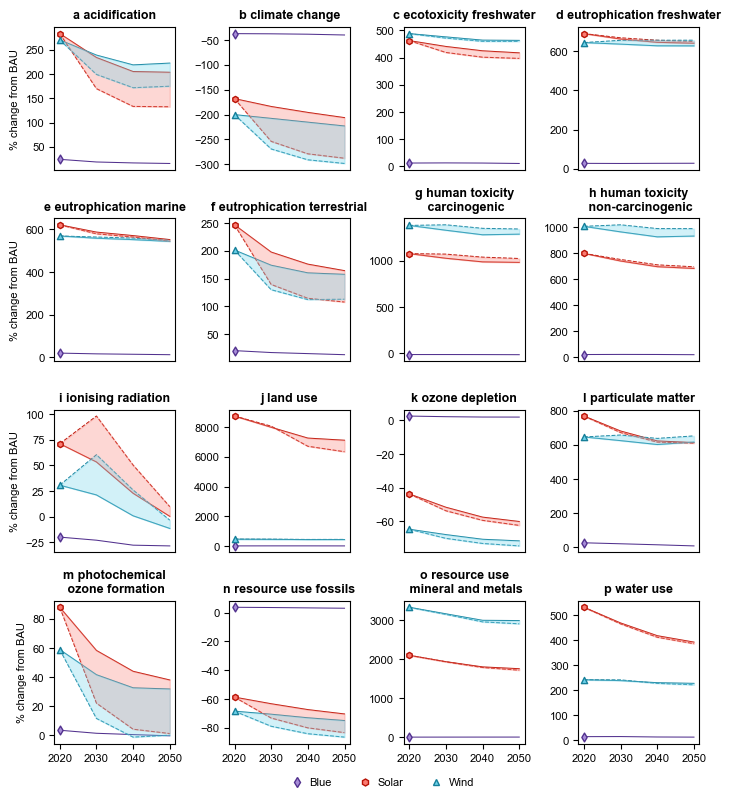

In [11]:
fig, ax = plt.subplots(4, 4, figsize = (fig_length[2], fig_height*0.8))

for i in range(0, len(impactCategories)):

    methanolResult = methanolResults[impactCategories[i]]
    methanolResultsRCP6 = methanolResult[methanolResult['Database'].str.contains('Base')]
    methanolBAURCP6 = methanolResultsRCP6[methanolResultsRCP6['Activity'].str.contains('methanol, BAU')]
    methanolBlueRCP6 = methanolResultsRCP6[methanolResultsRCP6['Activity'].str.contains('methanol, blue')]
    methanolWindRCP6 = methanolResultsRCP6[methanolResultsRCP6['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 30 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
    methanolSolarRCP6 = methanolResultsRCP6[methanolResultsRCP6['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 30 bar, from PEM electrolysis, from solar electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]

    methanolResultsRCP19 = methanolResult[methanolResult['Database'].str.contains('Base 2020') | methanolResult['Database'].str.contains('RCP19')]
    methanolBAURCP19 = methanolResultsRCP19[methanolResultsRCP19['Activity'].str.contains('methanol, BAU')]
    methanolBlueRCP19 = methanolResultsRCP19[methanolResultsRCP19['Activity'].str.contains('ammoni, blue')]
    methanolWindRCP19 = methanolResultsRCP19[methanolResultsRCP19['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 30 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
    methanolSolarRCP19 = methanolResultsRCP19[methanolResultsRCP19['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 30 bar, from PEM electrolysis, from solar electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]

    methanolBAURCP6 = methanolBAURCP6.reset_index(drop=True)
    methanolBlueRCP6 = methanolBlueRCP6.reset_index(drop=True)
    methanolWindRCP6 = methanolWindRCP6.reset_index(drop = True)
    methanolSolarRCP6 = methanolSolarRCP6.reset_index(drop = True)
    blueRCP6 = (methanolBlueRCP6['Impact'] - methanolBAURCP6['Impact'])/methanolBAURCP6['Impact']*100
    windRCP6 = (methanolWindRCP6['Impact'] - methanolBAURCP6['Impact'])/methanolBAURCP6['Impact']*100
    solarRCP6 = (methanolSolarRCP6['Impact'] - methanolBAURCP6['Impact'])/methanolBAURCP6['Impact']*100

    methanolBAURCP19 = methanolBAURCP19.reset_index(drop=True)
    methanolBlueRCP19 = methanolBlueRCP19.reset_index(drop=True)
    methanolWindRCP19 = methanolWindRCP19.reset_index(drop = True)
    methanolSolarRCP19 = methanolSolarRCP19.reset_index(drop = True)
    blueRCP19 = (methanolBlueRCP19['Impact'] - methanolBAURCP19['Impact'])/methanolBAURCP19['Impact']*100
    windRCP19 = (methanolWindRCP19['Impact'] - methanolBAURCP19['Impact'])/methanolBAURCP19['Impact']*100
    solarRCP19 = (methanolSolarRCP19['Impact'] - methanolBAURCP19['Impact'])/methanolBAURCP19['Impact']*100

    ax[i // 4, i % 4].plot(years, blueRCP6, label = 'Blue', color = '#52318E', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, solarRCP6, label = 'Solar', color = '#B71205', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, windRCP6, label = 'Wind', color = '#167F99', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, blueRCP19, label = 'Blue', color = '#52318E', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 4, i % 4].plot(years, solarRCP19, label = 'Solar', color = '#B71205', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 4, i % 4].plot(years, windRCP19, label = 'Wind', color = '#167F99', zorder = 0, linewidth = 0.75, linestyle = '--')

    ax[i//4, i % 4].fill_between(years, blueRCP6, blueRCP19, color = '#A78DD8', alpha = 0.3, zorder = 0)
    ax[i//4, i % 4].fill_between(years, solarRCP6, solarRCP19, color = '#FB7B71', alpha = 0.3, zorder = 0)
    ax[i//4, i % 4].fill_between(years, windRCP6, windRCP19, color = '#6DD2EA', alpha = 0.3, zorder = 0)

    ax[i // 4, i % 4].scatter(years[0], blueRCP6[0], label = 'Blue', s = 20, 
                              marker = 'd', facecolor = '#A78DD8', edgecolors = '#52318E', zorder = 1)
    ax[i // 4, i % 4].scatter(years[0], solarRCP6[0], label = 'Solar', s = 20, 
                              marker = 'h', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 1)
    ax[i // 4, i % 4].scatter(years[0], windRCP6[0], label = 'Wind', s = 20, 
                              marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 1)
    

    ax[i // 4, i % 4].set_title(alphabets[i] + impactCategories[i], fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'human toxicity carcinogenic':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'human toxicity\n carcinogenic', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'human toxicity non-carcinogenic':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'human toxicity\n non-carcinogenic', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'photochemical ozone formation':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'photochemical\n ozone formation', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'resource use mineral and metals':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'resource use\n mineral and metals', fontweight = 'bold', fontsize = fontsize_title)

for i in range(0, 4):
    for j in range(0, 4):
        if i < 3:
            ax[i, j].set_xticks([])
        if j == 0:
            ax[i, j].set_ylabel(r'% change from BAU')

legend_elements2 = [Line2D([0], [0], marker = 'd', color = "none", 
                                             markerfacecolor ='#A78DD8', markeredgecolor = "#52318E",
                                             label = 'Blue', markersize = 5),
                   Line2D([0], [0], marker = 'h', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar', markersize = 5),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind', markersize = 5),]

legend1 = fig.legend(handles = legend_elements2, frameon = False, loc = "upper center", ncol = 3, 
          prop={"size":8}, bbox_to_anchor=(0.53, 0.01), handletextpad = 0.1)

plotPathPNG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Methanol image SSP2 GLO.png')
plotPathSVG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Methanol image SSP2 GLO.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')

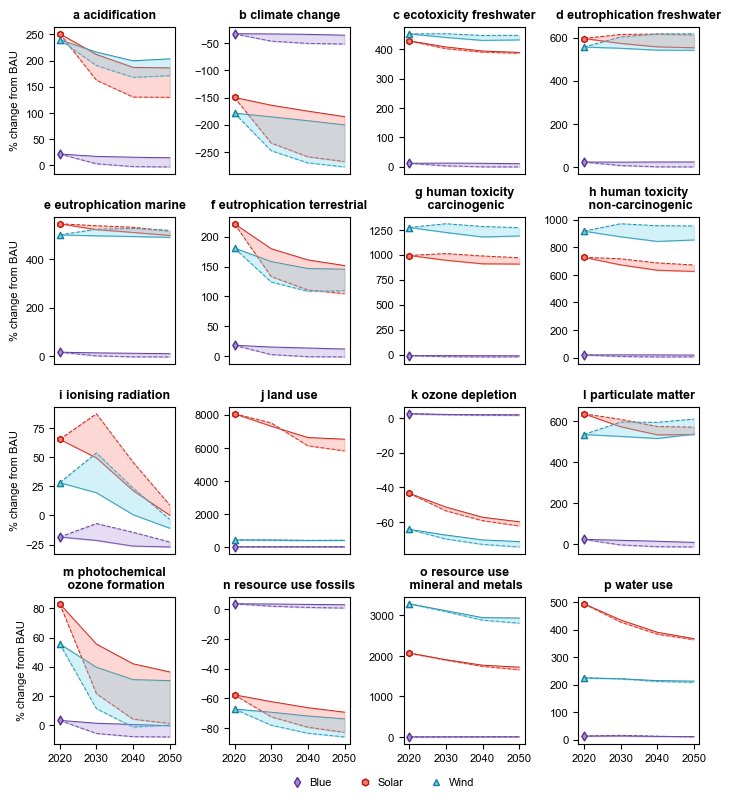

In [12]:
fig, ax = plt.subplots(4, 4, figsize = (fig_length[2], fig_height*0.8))

for i in range(0, len(impactCategories)):

    ethyleneResult = ethyleneResults[impactCategories[i]]
    ethyleneResultsRCP6 = ethyleneResult[ethyleneResult['Database'].str.contains('Base')]
    ethyleneBAURCP6 = ethyleneResultsRCP6[ethyleneResultsRCP6['Activity'].str.contains('ethylene, MTO; methanol, BAU')]
    ethyleneBlueRCP6 = ethyleneResultsRCP6[ethyleneResultsRCP6['Activity'].str.contains('ethylene, MTO; methanol, blue')]
    ethyleneWindRCP6 = ethyleneResultsRCP6[ethyleneResultsRCP6['Activity'].str.contains('ethylene, MTO; methanol synthesis, hydrogen production, gaseous, 30 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
    ethyleneSolarRCP6 = ethyleneResultsRCP6[ethyleneResultsRCP6['Activity'].str.contains('ethylene, MTO; methanol synthesis, hydrogen production, gaseous, 30 bar, from PEM electrolysis, from solar electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]

    ethyleneResultsRCP19 = ethyleneResult[ethyleneResult['Database'].str.contains('Base 2020') | ethyleneResult['Database'].str.contains('RCP19')]
    ethyleneBAURCP19 = ethyleneResultsRCP19[ethyleneResultsRCP19['Activity'].str.contains('ethylene, MTO; methanol, BAU')]
    ethyleneBlueRCP19 = ethyleneResultsRCP19[ethyleneResultsRCP19['Activity'].str.contains('ethylene, MTO; methanol, blue')]
    ethyleneWindRCP19 = ethyleneResultsRCP19[ethyleneResultsRCP19['Activity'].str.contains('ethylene, MTO; methanol synthesis, hydrogen production, gaseous, 30 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
    ethyleneSolarRCP19 = ethyleneResultsRCP19[ethyleneResultsRCP19['Activity'].str.contains('ethylene, MTO; methanol synthesis, hydrogen production, gaseous, 30 bar, from PEM electrolysis, from solar electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]

    ethyleneBAURCP6 = ethyleneBAURCP6.reset_index(drop=True)
    ethyleneBlueRCP6 = ethyleneBlueRCP6.reset_index(drop=True)
    ethyleneWindRCP6 = ethyleneWindRCP6.reset_index(drop = True)
    ethyleneSolarRCP6 = ethyleneSolarRCP6.reset_index(drop = True)
    blueRCP6 = (ethyleneBlueRCP6['Impact'] - ethyleneBAURCP6['Impact'])/ethyleneBAURCP6['Impact']*100
    windRCP6 = (ethyleneWindRCP6['Impact'] - ethyleneBAURCP6['Impact'])/ethyleneBAURCP6['Impact']*100
    solarRCP6 = (ethyleneSolarRCP6['Impact'] - ethyleneBAURCP6['Impact'])/ethyleneBAURCP6['Impact']*100

    ethyleneBAURCP19 = ethyleneBAURCP19.reset_index(drop=True)
    ethyleneBlueRCP19 = ethyleneBlueRCP19.reset_index(drop=True)
    ethyleneWindRCP19 = ethyleneWindRCP19.reset_index(drop = True)
    ethyleneSolarRCP19 = ethyleneSolarRCP19.reset_index(drop = True)
    blueRCP19 = (ethyleneBlueRCP19['Impact'] - ethyleneBAURCP19['Impact'])/ethyleneBAURCP19['Impact']*100
    windRCP19 = (ethyleneWindRCP19['Impact'] - ethyleneBAURCP19['Impact'])/ethyleneBAURCP19['Impact']*100
    solarRCP19 = (ethyleneSolarRCP19['Impact'] - ethyleneBAURCP19['Impact'])/ethyleneBAURCP19['Impact']*100

    ax[i // 4, i % 4].plot(years, blueRCP6, label = 'Blue', color = '#52318E', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, solarRCP6, label = 'Solar', color = '#B71205', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, windRCP6, label = 'Wind', color = '#167F99', zorder = 0, linewidth = 0.75)
    ax[i // 4, i % 4].plot(years, blueRCP19, label = 'Blue', color = '#52318E', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 4, i % 4].plot(years, solarRCP19, label = 'Solar', color = '#B71205', zorder = 0, linewidth = 0.75, linestyle = '--')
    ax[i // 4, i % 4].plot(years, windRCP19, label = 'Wind', color = '#167F99', zorder = 0, linewidth = 0.75, linestyle = '--')

    ax[i//4, i % 4].fill_between(years, blueRCP6, blueRCP19, color = '#A78DD8', alpha = 0.3, zorder = 0)
    ax[i//4, i % 4].fill_between(years, solarRCP6, solarRCP19, color = '#FB7B71', alpha = 0.3, zorder = 0)
    ax[i//4, i % 4].fill_between(years, windRCP6, windRCP19, color = '#6DD2EA', alpha = 0.3, zorder = 0)

    ax[i // 4, i % 4].scatter(years[0], blueRCP6[0], label = 'Blue', s = 20, 
                              marker = 'd', facecolor = '#A78DD8', edgecolors = '#52318E', zorder = 1)
    ax[i // 4, i % 4].scatter(years[0], solarRCP6[0], label = 'Solar', s = 20, 
                              marker = 'h', facecolor = '#FB7B71', edgecolors = '#B71205', zorder = 1)
    ax[i // 4, i % 4].scatter(years[0], windRCP6[0], label = 'Wind', s = 20, 
                              marker = '^', facecolor = '#6DD2EA', edgecolors = '#167F99', zorder = 1)
    

    ax[i // 4, i % 4].set_title(alphabets[i] + impactCategories[i], fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'human toxicity carcinogenic':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'human toxicity\n carcinogenic', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'human toxicity non-carcinogenic':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'human toxicity\n non-carcinogenic', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'photochemical ozone formation':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'photochemical\n ozone formation', fontweight = 'bold', fontsize = fontsize_title)
    if impactCategories[i] == 'resource use mineral and metals':
        ax[i // 4, i % 4].set_title(alphabets[i] + 'resource use\n mineral and metals', fontweight = 'bold', fontsize = fontsize_title)

for i in range(0, 4):
    for j in range(0, 4):
        if i < 3:
            ax[i, j].set_xticks([])
        if j == 0:
            ax[i, j].set_ylabel(r'% change from BAU')

legend_elements2 = [Line2D([0], [0], marker = 'd', color = "none", 
                                             markerfacecolor ='#A78DD8', markeredgecolor = "#52318E",
                                             label = 'Blue', markersize = 5),
                   Line2D([0], [0], marker = 'h', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar', markersize = 5),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind', markersize = 5),]

legend1 = fig.legend(handles = legend_elements2, frameon = False, loc = "upper center", ncol = 3, 
          prop={"size":8}, bbox_to_anchor=(0.53, 0.01), handletextpad = 0.1)

plotPathPNG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Ethylene image SSP2 GLO.png')
plotPathSVG = os.path.join('..', 'Plots', 'Phase 2', 'Burden shifting', 'Ethylene image SSP2 GLO.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')